Shape: (3051, 18)
Index(['HR', 'HRV_RMSSD', 'RR_diff_std', 'HRV_SDNN', 'RR_mean', 'RR_std',
       'RR_min', 'RR_max', 'RR_count', 'RR_quality', 'RR_valid', 'EDA_Tonic',
       'EDA_Phasic', 'SCR_Rate', 'participant', 'time_sec', 'EDA_Tonic_log',
       'EDA_Phasic_log'],
      dtype='str')

=== DESCRIBE ===
                HR    HRV_RMSSD  RR_diff_std     HRV_SDNN      RR_mean  \
count  3051.000000  3051.000000  3051.000000  3051.000000  3051.000000   
mean     81.930266    48.556538    48.392199    64.569922   749.630941   
std      11.610331    15.553781    15.420754    24.197213   100.850503   
min      57.700334    10.025740     9.961399    16.539736   449.291339   
25%      73.916298    36.889906    36.828957    46.998276   678.323864   
50%      80.901583    49.244289    49.109144    61.899927   744.250000   
75%      89.156594    60.675454    60.301061    79.272807   812.910959   
max     150.298709    86.746758    86.572117   175.651178  1020.754717   

            RR_std     

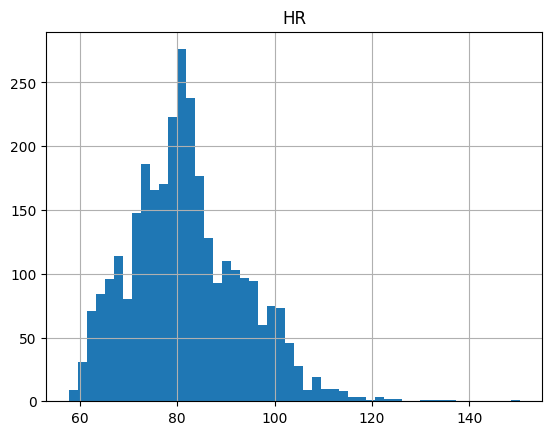

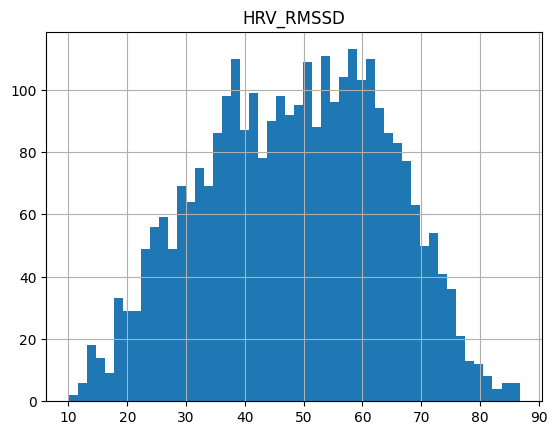

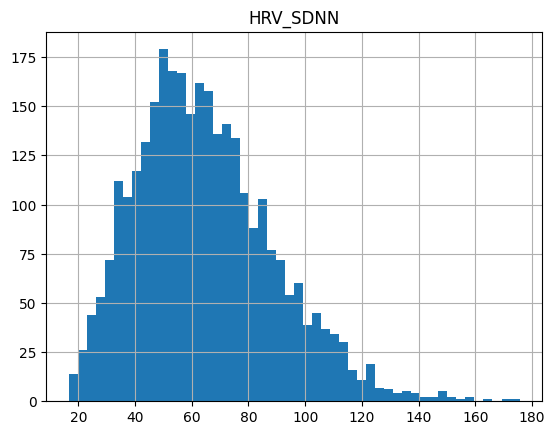

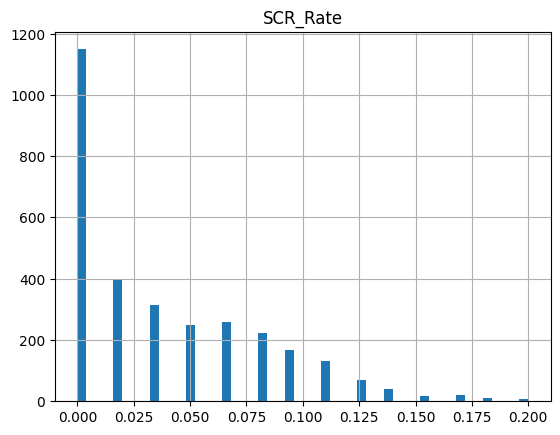

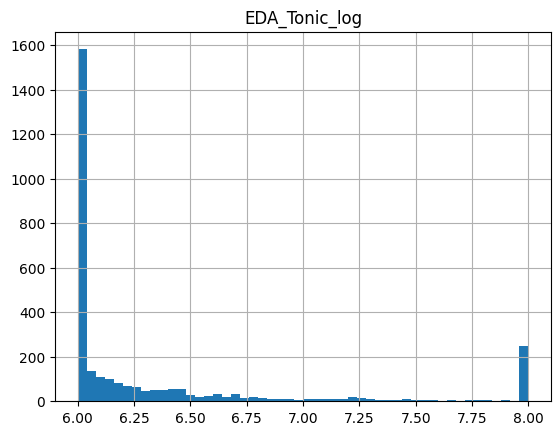

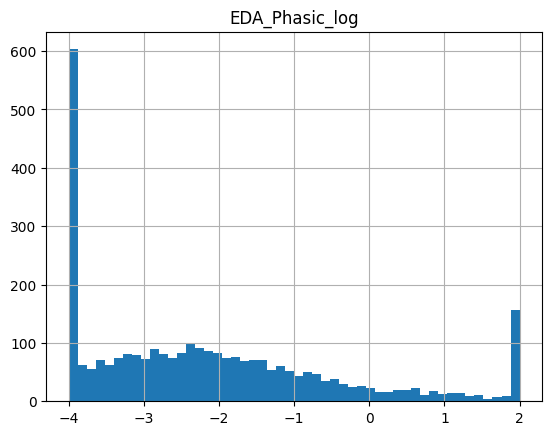


=== RANGE FLAGS ===
HR < 40: 0.0
HR > 150: 0.00032776138970829236
RMSSD > 120: 0.0
RMSSD < 10: 0.0
SDNN > 120: 0.021304490331039004
SDNN < 10: 0.0
SCR == 0: 0.37659783677482794


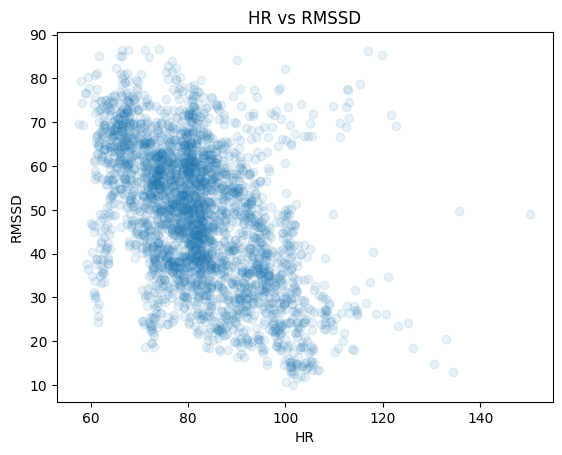


=== HRV NaN ratio ===
0.0

=== EXTREME RMSSD (>120) ===
Empty DataFrame
Columns: [HR, HRV_RMSSD, RR_diff_std, HRV_SDNN, RR_mean, RR_std, RR_min, RR_max, RR_count, RR_quality, RR_valid, EDA_Tonic, EDA_Phasic, SCR_Rate, participant, time_sec, EDA_Tonic_log, EDA_Phasic_log]
Index: []

=== EXTREME HR (<40 or >150) ===
           HR  HRV_RMSSD  RR_diff_std   HRV_SDNN     RR_mean      RR_std  \
0  150.298709  49.106299    46.426593  170.00903  624.035088  168.511124   

   RR_min  RR_max  RR_count  RR_quality  RR_valid   EDA_Tonic  EDA_Phasic  \
0   410.0  1150.0        57       0.625         1  753.683738    0.000325   

   SCR_Rate  participant  time_sec  EDA_Tonic_log  EDA_Phasic_log  
0  0.016529            1         0       6.903592            -4.0  

=== QUICK SUMMARY ===
{'high_rmssd_ratio': 0.0, 'low_hr_ratio': 0.0, 'high_hr_ratio': 0.00032776138970829236, 'scr_zero_ratio': 0.37659783677482794, 'nan_ratio': 0.0}


In [12]:
# Feature Validity Check Notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# =========================
# LOAD DATA
# =========================
FILE_PATH = Path("../data/features_extraction_win60_fix_order.csv")  # ändra

df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
print(df.columns)

# =========================
# BASIC STATS
# =========================
print("\n=== DESCRIBE ===")
print(df.describe())

print("\n=== NaN CHECK ===")
print(df.isna().mean())

# =========================
# HISTOGRAMS
# =========================
features = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Rate",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

for f in features:
    plt.figure()
    df[f].hist(bins=50)
    plt.title(f)
    plt.show()

# =========================
# RANGE CHECKS
# =========================
print("\n=== RANGE FLAGS ===")

print("HR < 40:", (df["HR"] < 40).mean())
print("HR > 150:", (df["HR"] > 150).mean())

print("RMSSD > 120:", (df["HRV_RMSSD"] > 120).mean())
print("RMSSD < 10:", (df["HRV_RMSSD"] < 10).mean())

print("SDNN > 120:", (df["HRV_SDNN"] > 120).mean())
print("SDNN < 10:", (df["HRV_SDNN"] < 10).mean())

print("SCR == 0:", (df["SCR_Rate"] == 0).mean())

# =========================
# HR vs RMSSD
# =========================
plt.figure()
plt.scatter(df["HR"], df["HRV_RMSSD"], alpha=0.1)
plt.xlabel("HR")
plt.ylabel("RMSSD")
plt.title("HR vs RMSSD")
plt.show()


# =========================
# WINDOW QUALITY
# =========================
print("\n=== HRV NaN ratio ===")
print(df["HRV_RMSSD"].isna().mean())

# =========================
# EXTREME VALUES SAMPLE
# =========================
print("\n=== EXTREME RMSSD (>120) ===")
print(df[df["HRV_RMSSD"] > 120].head())

print("\n=== EXTREME HR (<40 or >150) ===")
print(df[(df["HR"] < 40) | (df["HR"] > 150)].head())

# =========================
# SUMMARY FLAGS
# =========================
print("\n=== QUICK SUMMARY ===")
print({
    "high_rmssd_ratio": float((df["HRV_RMSSD"] > 120).mean()),
    "low_hr_ratio": float((df["HR"] < 40).mean()),
    "high_hr_ratio": float((df["HR"] > 150).mean()),
    "scr_zero_ratio": float((df["SCR_Rate"] == 0).mean()),
    "nan_ratio": float(df["HRV_RMSSD"].isna().mean())
})



=== RR DESCRIBE ===
           RR_mean       RR_std       RR_min       RR_max     RR_count  \
count  3051.000000  3051.000000  3051.000000  3051.000000  3051.000000   
mean    749.630941    64.154798   578.751229   937.505736    81.123894   
std     100.850503    24.022801   102.236694   131.312690    11.164951   
min     449.291339    16.462266   405.000000   505.000000    53.000000   
25%     678.323864    46.737993   500.000000   850.000000    74.000000   
50%     744.250000    61.497190   570.000000   945.000000    80.000000   
75%     812.910959    78.730600   652.500000  1040.000000    88.000000   
max    1020.754717   174.354841   930.000000  1195.000000   128.000000   

       RR_diff_std  RR_valid  
count  3051.000000    3051.0  
mean     48.392199       1.0  
std      15.420754       0.0  
min       9.961399       1.0  
25%      36.828957       1.0  
50%      49.109144       1.0  
75%      60.301061       1.0  
max      86.572117       1.0  

=== RR RANGE FLAGS ===
RR_min < 

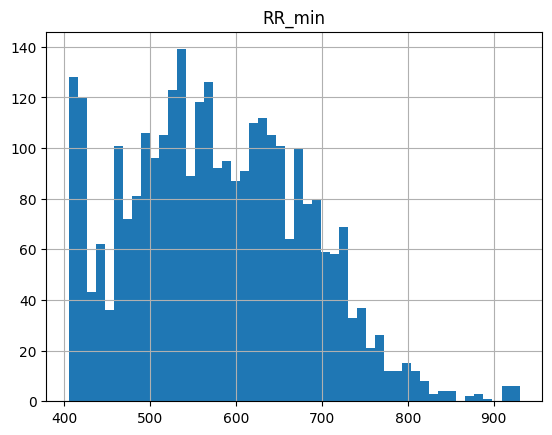

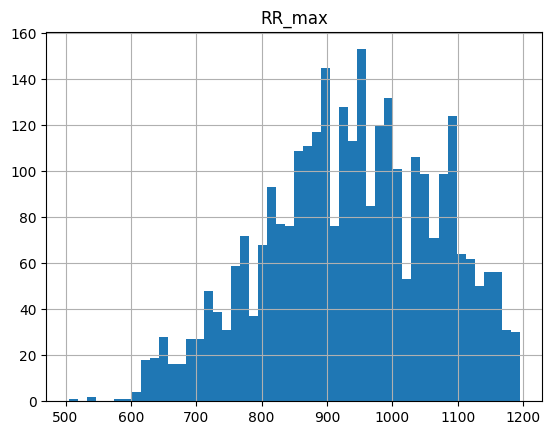

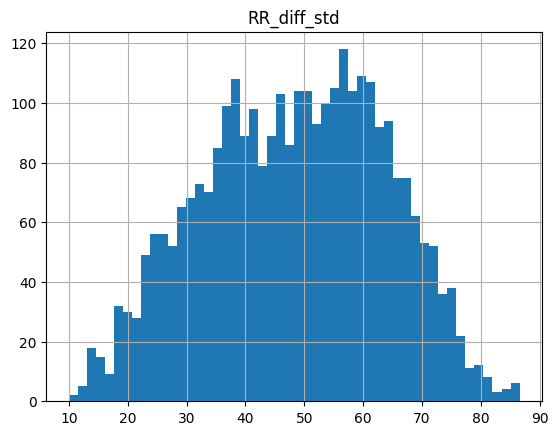


=== HR vs RR consistency ===
Mean error (bpm): 0.47118038795425393
Median error (bpm): 0.09842537680916053


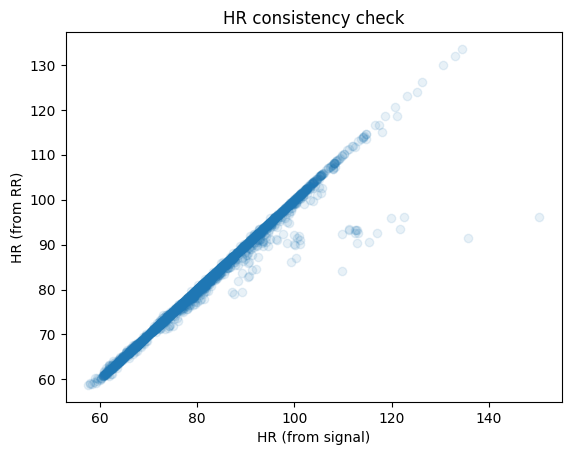


=== BAD WINDOWS SAMPLE ===
Number of bad windows: 0
Ratio: 0.0

Sample:
Empty DataFrame
Columns: [HR, HRV_RMSSD, RR_diff_std, HRV_SDNN, RR_mean, RR_std, RR_min, RR_max, RR_count, RR_quality, RR_valid, EDA_Tonic, EDA_Phasic, SCR_Rate, participant, time_sec, EDA_Tonic_log, EDA_Phasic_log, HR_from_RR]
Index: []


In [13]:
# =========================
# RR / IBI VALIDITY CHECK
# =========================

rr_features = [
    "RR_mean",
    "RR_std",
    "RR_min",
    "RR_max",
    "RR_count",
    "RR_diff_std",
    "RR_valid"
]

print("\n=== RR DESCRIBE ===")
print(df[rr_features].describe())

# -------------------------
# Range checks
# -------------------------
print("\n=== RR RANGE FLAGS ===")

print("RR_min < 300 ms:", (df["RR_min"] < 300).mean())
print("RR_max > 1500 ms:", (df["RR_max"] > 1500).mean())

print("RR_diff_std > 100:", (df["RR_diff_std"] > 100).mean())

print("RR_valid == 0:", (df["RR_valid"] == 0).mean())

# -------------------------
# Histograms
# -------------------------
import matplotlib.pyplot as plt

for f in ["RR_min", "RR_max", "RR_diff_std"]:
    plt.figure()
    df[f].hist(bins=50)
    plt.title(f)
    plt.show()

# -------------------------
# HR consistency check
# -------------------------
df["HR_from_RR"] = 60000 / df["RR_mean"]

error = np.abs(df["HR"] - df["HR_from_RR"])

print("\n=== HR vs RR consistency ===")
print("Mean error (bpm):", error.mean())
print("Median error (bpm):", np.median(error))

plt.figure()
plt.scatter(df["HR"], df["HR_from_RR"], alpha=0.1)
plt.xlabel("HR (from signal)")
plt.ylabel("HR (from RR)")
plt.title("HR consistency check")
plt.show()

# -------------------------
# Problematic windows
# -------------------------
print("\n=== BAD WINDOWS SAMPLE ===")

bad_windows = df[
    (df["RR_min"] < 300) |
    (df["RR_max"] > 1500) |
    (df["RR_diff_std"] > 100)
]

print("Number of bad windows:", len(bad_windows))
print("Ratio:", len(bad_windows) / len(df))

print("\nSample:")
print(bad_windows.head())

<Axes: >

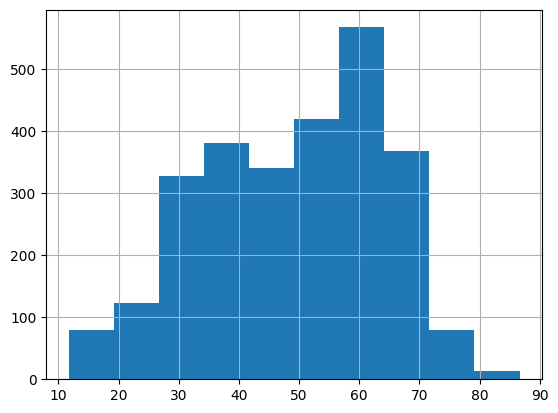

In [5]:
df["HRV_RMSSD"].describe()
df["HRV_RMSSD"].hist()

In [ ]:
df["HRV_RMSSD"].describe()